# Smart MCQ Solver Challenge (DL & GenAI Project)

In [270]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


## Load the datasets

In [271]:
df1 = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
df2 = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [272]:
print(df1.shape)
print(df2.shape)
print(sample.shape)

(2000, 8)
(500, 7)
(500, 2)


## Import libraries

In [273]:
# Part 1 : Setup + Pairwise Dataset Creation

import os
import re
import random
import warnings

import numpy as np
import pandas as pd

from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


## Set Configurations

In [274]:
## Set Configurations

class CFG:

    # Randomness
    SEED = 42

    # Dataset
    NUM_CLASSES = 5

    # Text
    MAX_LEN = 320

    # Vocabulary
    MIN_FREQ = 2
    MAX_VOCAB_SIZE = 5000

    # DataLoader
    BATCH_SIZE = 32
    NUM_WORKERS = 2

    # Training (used later)
    EPOCHS = 20
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-5

    # Model
    EMBEDDING_DIM = 300
    HIDDEN_DIM = 128
    DROPOUT = 0.40

print(CFG.__dict__)

{'__module__': '__main__', 'SEED': 42, 'NUM_CLASSES': 5, 'MAX_LEN': 320, 'MIN_FREQ': 2, 'MAX_VOCAB_SIZE': 5000, 'BATCH_SIZE': 32, 'NUM_WORKERS': 2, 'EPOCHS': 20, 'LEARNING_RATE': 0.001, 'WEIGHT_DECAY': 1e-05, 'EMBEDDING_DIM': 300, 'HIDDEN_DIM': 128, 'DROPOUT': 0.4, '__dict__': <attribute '__dict__' of 'CFG' objects>, '__weakref__': <attribute '__weakref__' of 'CFG' objects>, '__doc__': None}


In [275]:
# Random Seed

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG.SEED)

print("Random Seed Set:", CFG.SEED)

Random Seed Set: 42


### Device setups

In [276]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 50)
print("Device :", DEVICE)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

print("=" * 50)

Device : cuda
GPU : Tesla T4


In [277]:
train = df1.copy()
test = df2.copy()

In [278]:
print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

train.head()

Train Shape : (2000, 8)
Test Shape  : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


## Part - 1 (Pairwise Dataset Creation)

In [279]:
# Pairwise Dataset Creation

OPTION_COLUMNS = ["A", "B", "C", "D", "E"]


def create_pairwise_dataset(df):

    samples = []

    for _, row in df.iterrows():

        question = str(row["prompt"])

        correct_answer = row["answer"]

        question_id = row["id"]

        for option in OPTION_COLUMNS:

            option_text = str(row[option])

            # Structured input text
            text = (
                f"Question: {question} "
                f"[SEP] "
                f"Option: {option_text}"
            )

            label = int(option == correct_answer)

            samples.append(
                {
                    "question_id": question_id,
                    "option": option,
                    "text": text,
                    "label": label
                }
            )

    return pd.DataFrame(samples)

In [280]:
pairwise_train = create_pairwise_dataset(train)

print(pairwise_train.shape)

pairwise_train.head(10)

(10000, 4)


,question_id,option,text,label
0,1,A,Question: Pick the best possible answer: What ...,0
1,1,B,Question: Pick the best possible answer: What ...,1
2,1,C,Question: Pick the best possible answer: What ...,0
3,1,D,Question: Pick the best possible answer: What ...,0
4,1,E,Question: Pick the best possible answer: What ...,0
5,2,A,Question: What is accelerator-based light-ion ...,1
6,2,B,Question: What is accelerator-based light-ion ...,0
7,2,C,Question: What is accelerator-based light-ion ...,0
8,2,D,Question: What is accelerator-based light-ion ...,0
9,2,E,Question: What is accelerator-based light-ion ...,0


In [281]:
#### Each question has only one correct answer
pairwise_train.groupby("question_id")["label"].sum().value_counts()

label
1    2000
Name: count, dtype: int64

In [282]:
### Check Class Balance
pairwise_train["label"].value_counts()

label
0    8000
1    2000
Name: count, dtype: int64

## Create Pairwise Test Dataset

In [283]:
### Create Pairwise Test Dataset

# Pairwise Test Dataset
    
def create_test_pairs(df):

    samples = []

    for _, row in df.iterrows():

        question = str(row["prompt"])

        question_id = row["id"]

        for option in OPTION_COLUMNS:

            option_text = str(row[option])

            text = (
                f"Question: {question} "
                f"[SEP] "
                f"Option: {option_text}"
            )

            samples.append(
                {
                    "question_id": question_id,
                    "option": option,
                    "text": text
                }
            )

    return pd.DataFrame(samples)

In [284]:
pairwise_test = create_test_pairs(test)

print(pairwise_test.shape)

pairwise_test.head()

(2500, 3)


,question_id,option,text
0,1,A,Question: Pick the best possible answer: What ...
1,1,B,Question: Pick the best possible answer: What ...
2,1,C,Question: Pick the best possible answer: What ...
3,1,D,Question: Pick the best possible answer: What ...
4,1,E,Question: Pick the best possible answer: What ...


In [285]:
### Sanity check

print("=" * 60)
print("Original Train :", train.shape)
print("Pairwise Train :", pairwise_train.shape)
print()
print("Original Test :", test.shape)
print("Pairwise Test :", pairwise_test.shape)
print("=" * 60)

Original Train : (2000, 8)
Pairwise Train : (10000, 4)

Original Test : (500, 7)
Pairwise Test : (2500, 3)


In [286]:
### Save pair-wise files
pairwise_train.to_csv(
    "pairwise_train.csv",
    index=False
)

pairwise_test.to_csv(
    "pairwise_test.csv",
    index=False
)

print("Pairwise datasets saved successfully.")

Pairwise datasets saved successfully.


## Part - 2 (Text Preprocessing)

In [287]:
#### PART 2 : TEXT PREPROCESSING

from collections import Counter
import re
import string

from tqdm.auto import tqdm

tqdm.pandas()

### Text cleaning

In [288]:
## Text Cleaning Function


def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # remove newline
    text = text.replace("\n", " ")

    # remove tabs
    text = text.replace("\t", " ")

    # multiple spaces
    text = re.sub(r"\s+", " ", text)

    # strip spaces
    text = text.strip()

    return text

In [289]:
pairwise_train["clean_text"] = pairwise_train["text"].progress_apply(clean_text)

pairwise_test["clean_text"] = pairwise_test["text"].progress_apply(clean_text)

print("Cleaning Completed")

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

Cleaning Completed


In [290]:
### Inspect Results
pairwise_train[["text","clean_text"]].head()

,text,clean_text
0,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...
1,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...
2,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...
3,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...
4,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...


### Vocabulary building

In [291]:
## Vocabulary Builder

counter = Counter()

for text in tqdm(pairwise_train["clean_text"]):

    # Better tokenization
    tokens = re.findall(r"\w+|[^\w\s]", text.lower())

    counter.update(tokens)

print("Unique Words:", len(counter))

  0%|          | 0/10000 [00:00<?, ?it/s]

Unique Words: 3016


In [292]:
### Most Common Words
counter.most_common(20)

[('the', 49398),
 (':', 27835),
 ('of', 20662),
 ('.', 19939),
 ('is', 18126),
 ('a', 13524),
 ('option', 13040),
 ('?', 11410),
 (',', 11213),
 ('question', 10000),
 ('[', 10000),
 ('sep', 10000),
 (']', 10000),
 ('in', 9528),
 ('what', 9045),
 ('and', 8731),
 ('to', 7534),
 ('-', 6160),
 ('correct', 5875),
 ('that', 4928)]

In [293]:
### Build Vocabulary

vocab = {
    "<PAD>":0,
    "<UNK>":1
}

most_common = counter.most_common(
    CFG.MAX_VOCAB_SIZE-2
)

for word,_ in most_common:

    vocab[word] = len(vocab)

print("Vocabulary Size:",len(vocab))

Vocabulary Size: 3018


In [294]:
### Reverse Vocabulary

idx2word = {

    idx:word

    for word,idx

    in vocab.items()

}

In [295]:
### Vocabulary Statistics
print("="*50)

print("Vocabulary Size :",len(vocab))

print("PAD Token :",vocab["<PAD>"])

print("UNK Token :",vocab["<UNK>"])

print("="*50)

Vocabulary Size : 3018
PAD Token : 0
UNK Token : 1


## Tokenizer

In [296]:
### Tokenizer

def tokenize(text):

    # Better tokenization
    words = re.findall(r"\w+|[^\w\s]", text.lower())

    tokens = [
        vocab.get(word, vocab["<UNK>"])
        for word in words
    ]

    return tokens

## Integer Encoding

In [297]:
## Integer Encoding

pairwise_train["tokens"] = (

    pairwise_train["clean_text"]

    .progress_apply(tokenize)

)

pairwise_test["tokens"] = (pairwise_test["clean_text"].progress_apply(tokenize))

print("Tokenization Finished")

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

Tokenization Finished


In [298]:
### Inspect Tokens
pairwise_train[["clean_text","tokens"]].head()

,clean_text,tokens
0,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."
1,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."
2,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."
3,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."
4,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."


In [299]:
#### Token Length Analysis
pairwise_train["token_length"] = (pairwise_train["tokens"].apply(len))

pairwise_train["token_length"].describe()

count    10000.000000
mean        58.902300
std         21.724529
min         19.000000
25%         43.000000
50%         54.000000
75%         71.000000
max        190.000000
Name: token_length, dtype: float64

## Padding

In [300]:
### Padding

def pad_sequence(sequence, max_len=CFG.MAX_LEN):

    if len(sequence)>=max_len:

        return sequence[:max_len]

    padding = [vocab["<PAD>"]]*(max_len-len(sequence))

    return sequence+padding

In [301]:
pairwise_train["input_ids"]=(

    pairwise_train["tokens"]

    .progress_apply(pad_sequence)

)

pairwise_test["input_ids"]=(pairwise_test["tokens"].progress_apply(pad_sequence))

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

In [302]:
### Verify padding
pairwise_train["input_ids"].apply(len).value_counts()

input_ids
320    10000
Name: count, dtype: int64

In [303]:
### Convert labels
pairwise_train["label"].value_counts()

label
0    8000
1    2000
Name: count, dtype: int64

In [304]:
pairwise_train.head()

,question_id,option,text,label,clean_text,tokens,token_length,input_ids
0,1,A,Question: Pick the best possible answer: What ...,0,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,...",90,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."
1,1,B,Question: Pick the best possible answer: What ...,1,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,...",81,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."
2,1,C,Question: Pick the best possible answer: What ...,0,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,...",75,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."
3,1,D,Question: Pick the best possible answer: What ...,0,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,...",68,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."
4,1,E,Question: Pick the best possible answer: What ...,0,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,...",70,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 600, 601,..."


In [305]:
pairwise_test.head()

,question_id,option,text,clean_text,tokens,input_ids
0,1,A,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41...","[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41..."
1,1,B,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41...","[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41..."
2,1,C,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41...","[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41..."
3,1,D,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41...","[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41..."
4,1,E,Question: Pick the best possible answer: What ...,question: pick the best possible answer: what ...,"[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41...","[11, 3, 51, 2, 52, 50, 26, 3, 16, 6, 2, 68, 41..."


In [306]:
### Save Files
pairwise_train.to_pickle(
    "pairwise_train_processed.pkl"
)

pairwise_test.to_pickle(
    "pairwise_test_processed.pkl"
)

print("Processed datasets saved.")

Processed datasets saved.


## Part - 3 (Train & Validation Split)

In [307]:
# Train / Validation Split

question_ids = pairwise_train["question_id"].unique()

train_ids, valid_ids = train_test_split(
    question_ids,
    test_size=0.2,
    random_state=CFG.SEED,
    shuffle=True
)

train_df = pairwise_train[
    pairwise_train["question_id"].isin(train_ids)
].reset_index(drop=True)

valid_df = pairwise_train[
    pairwise_train["question_id"].isin(valid_ids)
].reset_index(drop=True)

print("="*50)
print("Train Questions :", len(train_ids))
print("Validation Questions :", len(valid_ids))
print()
print("Train Samples :", len(train_df))
print("Validation Samples :", len(valid_df))
print("="*50)

Train Questions : 1600
Validation Questions : 400

Train Samples : 8000
Validation Samples : 2000


In [308]:
# Verify No overlapping questions

overlap = set(train_ids) & set(valid_ids)

print("Overlapping Question IDs:", len(overlap))

Overlapping Question IDs: 0


## PyTorch dataset

In [309]:
## PyTorch Dataset

class MCQDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        return {
            "input_ids": torch.tensor(
                row["input_ids"],
                dtype=torch.long
            ),

            "label": torch.tensor(
                row["label"],
                dtype=torch.float32
            ),

            "question_id": row["question_id"],
            "option": row["option"]
        }

In [310]:
### Create Dataset Objects
train_dataset = MCQDataset(train_df)

valid_dataset = MCQDataset(valid_df)

test_dataset = MCQDataset(pairwise_test)

print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

8000
2000
2500


### Custom collate_fn

Although all sequences are already padded to MAX_LEN, a custom collate_fn makes batching explicit and keeps metadata (question_id, option) intact for later ranking.


In [311]:
### Custom collate_fn

def collate_fn(batch):

    input_ids = torch.stack(
        [item["input_ids"] for item in batch]
    )

    labels = torch.stack(
        [item["label"] for item in batch]
    )

    question_ids = [
        item["question_id"] for item in batch
    ]

    options = [
        item["option"] for item in batch
    ]

    return {
        "input_ids": input_ids,
        "labels": labels,
        "question_ids": question_ids,
        "options": options
    }

## DataLoader

In [312]:
## DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)


valid_loader = DataLoader(
    valid_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn
)

In [313]:
## Verify One Batch

batch = next(iter(train_loader))

print("="*50)

print("Input Shape :", batch["input_ids"].shape)
print("Labels Shape :", batch["labels"].shape)
print("Question IDs :", batch["question_ids"][:5])
print("Options :", batch["options"][:5])

print("="*50)

Input Shape : torch.Size([32, 320])
Labels Shape : torch.Size([32])
Question IDs : [np.int64(1258), np.int64(946), np.int64(1459), np.int64(76), np.int64(1993)]
Options : ['D', 'B', 'E', 'A', 'C']


In [314]:
### Check Label Distribution
train_df["label"].value_counts(normalize=True)

label
0    0.8
1    0.2
Name: proportion, dtype: float64

In [315]:
### Check Tensor Types
print(batch["input_ids"].dtype)
print(batch["labels"].dtype)

## Check Sequence Length
print(batch["input_ids"].shape[1])

torch.int64
torch.float32
320


In [316]:
### Check Device Transfer
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(DEVICE)
labels = batch["labels"].to(DEVICE)

print(input_ids.device)
print(labels.device)

cuda:0
cuda:0


In [317]:
### Summary
print("="*60)
print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(valid_dataset))
print("Test Dataset :", len(test_dataset))
print()
print("Batch Size :", CFG.BATCH_SIZE)
print("Sequence Length :", CFG.MAX_LEN)
print("Vocabulary Size :", len(vocab))
print("="*60)

Train Dataset : 8000
Validation Dataset : 2000
Test Dataset : 2500

Batch Size : 32
Sequence Length : 320
Vocabulary Size : 3018


## Part - 4 (BiLSTM + Attention model)

In [318]:
## PART 4 : MODEL

import torch
import torch.nn as nn

In [319]:
#### Attention Layer

class Attention(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attention = nn.Linear(
            hidden_dim * 2,
            1
        )

    def forward(self, lstm_output):

        # (batch, seq_len, 1)

        scores = self.attention(
            lstm_output
        )

        weights = torch.softmax(
            scores,
            dim=1
        )

        context = torch.sum(
            weights * lstm_output,
            dim=1
        )

        return context

In [320]:
## BiLSTM + Attention

class BiLSTMAttention(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        dropout
    ):

        super().__init__()

        # Embedding

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # BiLSTM

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Attention
        self.attention = Attention(hidden_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully Connected
        self.fc1 = nn.Linear(
            hidden_dim * 2,
            128
        )

        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(
            128,
            1
        )

    def forward(self, input_ids):
        
        x = self.embedding(input_ids)
        lstm_output, _ = self.lstm(x)
        
        context = self.attention(
            lstm_output
        )

        context = self.dropout(
            context
        )

        x = self.fc1(context)
        x = self.relu(x)
        x = self.dropout(x)

        logits = self.fc2(x)

        return logits.squeeze(1)

In [321]:
### instantiate Model
# model = BiLSTMAttention(
#     vocab_size=len(vocab),
#     embedding_dim=CFG.EMBEDDING_DIM,
#     hidden_dim=CFG.HIDDEN_DIM,
#     dropout=CFG.DROPOUT
# )

# model.to(DEVICE)

model = BiLSTMAttention(
    vocab_size=len(vocab),
    embedding_dim=CFG.EMBEDDING_DIM,
    hidden_dim=CFG.HIDDEN_DIM,
    dropout=CFG.DROPOUT
).to(DEVICE)


model.eval()

BiLSTMAttention(
  (embedding): Embedding(3018, 300, padding_idx=0)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [322]:
print(model)

BiLSTMAttention(
  (embedding): Embedding(3018, 300, padding_idx=0)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [323]:
### Count Parameters
def count_parameters(model):

    return sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad
    )

print(

    f"Trainable Parameters: {count_parameters(model):,}"

)

Trainable Parameters: 1,379,002


In [324]:
### Forward Pass Test
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(DEVICE)

output = model(input_ids)

print(output.shape)

torch.Size([32])


## Part - 5 Training Loop

In [325]:
## PART 5.1 : TRAINING SETUP

import copy
import time
import numpy as np

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast

In [326]:
## Training Configuration

CFG.LR = 2e-3
CFG.WEIGHT_DECAY = 1e-4

CFG.EPOCHS = 20

CFG.GRAD_CLIP = 1.0

CFG.PATIENCE = 5

CFG.MIN_DELTA = 1e-4

## Loss Function

In [327]:
criterion = nn.BCEWithLogitsLoss()

## Optimizer

In [328]:
optimizer = AdamW(

    model.parameters(),

    lr=CFG.LR,

    weight_decay=CFG.WEIGHT_DECAY

)

In [329]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.EPOCHS,
    eta_min=1e-6
)

In [330]:
USE_AMP = torch.cuda.is_available()

scaler = GradScaler(enabled=USE_AMP)


### Gradient Clipping
## We'll apply gradient clipping during training.

torch.nn.utils.clip_grad_norm_(

    model.parameters(),

    CFG.GRAD_CLIP

)

tensor(0.)

In [331]:
## Average Meter

class AverageMeter:

    def __init__(self):
        self.reset()

    def reset(self):

        self.sum = 0.0
        self.count = 0
        self.avg = 0.0

    def update(self, value, n=1):

        self.sum += value * n
        self.count += n

        self.avg = self.sum / self.count

In [332]:
loss_meter = AverageMeter()

# loss_meter.update(loss.item(), batch_size)

print(loss_meter.avg)

0.0


In [333]:
## Early Stopping

class EarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience

        self.counter = 0

        self.best_score = -float("inf")

        self.best_model = None

        self.best_epoch = 0

        self.early_stop = False

    def __call__(self, score, model, epoch):

        if score > self.best_score:

            self.best_score = score

            self.best_epoch = epoch

            self.best_model = copy.deepcopy(model.state_dict())

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True



early_stopping = EarlyStopping()


In [334]:
## Save the best models

if early_stopping.best_model is not None:

    model.load_state_dict(early_stopping.best_model)


### Current learning rae
print(optimizer.param_groups[0]["lr"])

0.002


In [335]:
### Training Summary

print("="*60)

print("Loss Function :", criterion)
print("Optimizer :", optimizer.__class__.__name__)
print("Scheduler :", scheduler.__class__.__name__)
print("Mixed Precision :", USE_AMP)
print("Gradient Clip :", CFG.GRAD_CLIP)

print("="*60)

Loss Function : BCEWithLogitsLoss()
Optimizer : AdamW
Scheduler : CosineAnnealingLR
Mixed Precision : True
Gradient Clip : 1.0


In [336]:
from tqdm.auto import tqdm
from contextlib import nullcontext

In [337]:
# # Train One Epoch

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scheduler,
    scaler,
    device
):

    model.train()

    loss_meter = AverageMeter()

    all_preds = []
    all_labels = []

    progress_bar = tqdm(
        loader,
        total=len(loader),
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)

        amp_context = autocast() if USE_AMP else nullcontext()

        with amp_context:

            logits = model(input_ids)

            loss = criterion(logits, labels)

        if USE_AMP:

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                CFG.GRAD_CLIP
            )

            scaler.step(optimizer)

            scaler.update()

        else:

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                CFG.GRAD_CLIP
            )

            optimizer.step()

        loss_meter.update(
            loss.item(),
            input_ids.size(0)
        )

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).float()

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss_meter.avg:.4f}"
        )

    scheduler.step()

    accuracy = (
        np.array(all_preds) == np.array(all_labels)
    ).mean()

    return loss_meter.avg, accuracy

In [338]:
## Validation

def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    loss_meter = AverageMeter()

    all_preds = []
    all_labels = []

    all_logits = []

    question_ids = []

    options = []

    with torch.no_grad():

        progress_bar = tqdm(
            loader,
            total=len(loader),
            desc="Validation",
            leave=False
        )

        for batch in progress_bar:

            input_ids = batch["input_ids"].to(device)

            labels = batch["labels"].to(device)

            logits = model(input_ids)

            loss = criterion(
                logits,
                labels
            )

            loss_meter.update(
                loss.item(),
                input_ids.size(0)
            )

            probs = torch.sigmoid(logits)

            preds = (probs > 0.5).float()

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_logits.extend(
                probs.cpu().numpy()
            )

            question_ids.extend(
                batch["question_ids"]
            )

            options.extend(
                batch["options"]
            )

            progress_bar.set_postfix(
                loss=f"{loss_meter.avg:.4f}"
            )

    accuracy = (
        np.array(all_preds) ==
        np.array(all_labels)
    ).mean()

    return (
        loss_meter.avg,
        accuracy,
        np.array(all_logits),
        np.array(all_labels),
        question_ids,
        options
    )

In [339]:
dup = train.groupby("prompt").size()

print((dup > 1).sum())

212


In [340]:
train[
    train["prompt"] ==
    train.iloc[23]["prompt"]
]

,id,prompt,A,B,C,D,E,answer
23,24,Which of the following is correct? Which of th...,The blocking temperature of an antiferromagnet...,The blocking temperature of an antiferromagnet...,The blocking temperature of an antiferromagnet...,The blocking temperature of an antiferromagnet...,The blocking temperature of an antiferromagnet...,D
657,658,Which of the following is correct? Which of th...,The blocking temperature of an antiferromagnet...,The blocking temperature of an antiferromagnet...,The blocking temperature of an antiferromagnet...,The blocking temperature of an antiferromagnet...,The blocking temperature of an antiferromagnet...,D


## Test training

In [341]:
train_loss, train_acc = train_one_epoch(

    model=model,

    loader=train_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    scaler=scaler,

    device=DEVICE

)

print(train_loss)

print(train_acc)

Training:   0%|          | 0/250 [00:00<?, ?it/s]

0.4706369614303112
0.816


## Test Validation

In [342]:
## Test Validation

(
    valid_loss,
    valid_acc,
    logits,
    labels,
    question_ids,
    options
) = validate_one_epoch(

    model,

    valid_loader,

    criterion,

    DEVICE

)

print(valid_loss)

print(valid_acc)

Validation:   0%|          | 0/63 [00:00<?, ?it/s]

0.32304974031448364
0.879


In [343]:
### Verify Outputs
print(logits.shape)

print(labels.shape)

print(len(question_ids))

print(len(options))

(2000,)
(2000,)
2000
2000


In [344]:
## Average Precision @ K

def apk(actual, predicted, k=3):
    """
    actual: true answer label (e.g. 'B')
    predicted: ranked list like ['C','B','A']
    """

    predicted = predicted[:k]

    score = 0.0

    for i, p in enumerate(predicted):

        if p == actual:

            score = 1.0 / (i + 1)
            break

    return score

In [345]:
# MAP@3 Evaluation

def calculate_map3(
    scores,
    labels,
    question_ids,
    options
):

    df = pd.DataFrame({

        "question_id": question_ids,

        "option": options,

        "score": scores,

        "label": labels

    })

    map_scores = []

    grouped = df.groupby("question_id")

    for _, group in grouped:

        # True answer
        correct = group.loc[
            group["label"] == 1,
            "option"
        ].values[0]

        # Rank options
        ranked = group.sort_values(
            "score",
            ascending=False
        )

        top3 = ranked["option"].tolist()[:3]

        map_scores.append(

            apk(correct, top3, k=3))

    return np.mean(map_scores)

In [346]:
### Test MAP@3
map3 = calculate_map3(

    logits,
    labels,
    question_ids,
    options

)

print(f"Validation MAP@3 : {map3:.5f}")

Validation MAP@3 : 0.86542


In [347]:
### Inspect Predictions


prediction_df = pd.DataFrame({

    "question_id": question_ids,

    "option": options,

    "score": logits,

    "label": labels

})

prediction_df.head(15)

,question_id,option,score,label
0,24,A,0.074967,0.0
1,24,B,0.110445,0.0
2,24,C,0.082411,0.0
3,24,D,0.983824,1.0
4,24,E,0.085253,0.0
5,30,A,0.079570,0.0
6,30,B,0.978366,1.0
7,30,C,0.074366,0.0
8,30,D,0.085511,0.0
9,30,E,0.080251,0.0


In [348]:
### View Ranked Options
qid = prediction_df["question_id"].iloc[0]

prediction_df[
    prediction_df["question_id"] == qid
].sort_values(
    "score",
    ascending=False
)

,question_id,option,score,label
3,24,D,0.983824,1.0
1,24,B,0.110445,0.0
4,24,E,0.085253,0.0
2,24,C,0.082411,0.0
0,24,A,0.074967,0.0


## Generate Top-3 Predictions

In [349]:
### Generate Top-3 Predictions
def get_top3_predictions(
    scores,
    question_ids,
    options
):

    df = pd.DataFrame({

        "question_id": question_ids,

        "option": options,

        "score": scores

    })

    predictions = {}

    for qid, group in df.groupby("question_id"):

        ranked = group.sort_values(
            "score",
            ascending=False
        )

        predictions[qid] = ranked["option"].tolist()[:3]

    return predictions

In [350]:
top3 = get_top3_predictions(
    logits,
    question_ids,
    options
)

first_qid = next(iter(top3))
print(first_qid)
print(top3[first_qid])

24
['D', 'B', 'E']


### Complete Validation Pipeline

In [351]:
(
    valid_loss,
    _,
    scores,
    labels,
    question_ids,
    options
) = validate_one_epoch(
    model,
    valid_loader,
    criterion,
    DEVICE
)

valid_map3 = calculate_map3(
    scores,
    labels,
    question_ids,
    options
)

print(f"Validation Loss : {valid_loss:.4f}")
print(f"Validation MAP@3 : {valid_map3:.5f}")

Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Validation Loss : 0.3230
Validation MAP@3 : 0.86542


In [352]:
### Create History Dictionary
### Training History

history = {

    "train_loss": [],

    "valid_loss": [],

    "train_acc": [],

    "valid_acc": [],

    "map3": [],

    "lr": []

}

## Main Training Loop

In [353]:
## MAIN TRAINING LOOP
best_map3 = -float("inf")

best_epoch = -1

start_time = time.time()

for epoch in range(CFG.EPOCHS):

    print("=" * 70)
    print(f"Epoch {epoch+1}/{CFG.EPOCHS}")
    print("=" * 70)

    ## Train
    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        device=DEVICE
    )

    ## Validation
    (
        valid_loss,
        valid_acc,
        scores,
        labels,
        question_ids,
        options
    ) = validate_one_epoch(
        model=model,
        loader=valid_loader,
        criterion=criterion,
        device=DEVICE
    )

    ## MAP@3
    valid_map3 = calculate_map3(
        scores=scores,
        labels=labels,
        question_ids=question_ids,
        options=options
    )

    ## History
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    history["train_acc"].append(train_acc)
    history["valid_acc"].append(valid_acc)

    history["map3"].append(valid_map3)

    history["lr"].append(
        optimizer.param_groups[0]["lr"]
    )

    ### Best Model
    if valid_map3 > best_map3:

        best_map3 = valid_map3

        best_epoch = epoch + 1

        torch.save(

            model.state_dict(),

            "best_model.pth"

        )

        print("Best model saved!")

    
    ## Early Stopping
    early_stopping(

        score=valid_map3,

        model=model,

        epoch=epoch+1

    )

    ## Logging
    print()

    print(f"Train Loss      : {train_loss:.4f}")

    print(f"Validation Loss : {valid_loss:.4f}")

    print(f"Train Accuracy  : {train_acc:.4f}")

    print(f"Validation Acc. : {valid_acc:.4f}")

    print(f"Validation MAP3 : {valid_map3:.5f}")

    print(f"Learning Rate   : {optimizer.param_groups[0]['lr']:.6f}")

    print()

    if early_stopping.early_stop:

        print("="*60)

        print("Early Stopping Triggered")

        print("="*60)

        break

Epoch 1/20


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Best model saved!

Train Loss      : 0.2441
Validation Loss : 0.1680
Train Accuracy  : 0.9024
Validation Acc. : 0.9320
Validation MAP3 : 0.97542
Learning Rate   : 0.001951

Epoch 2/20


Training:   0%|          | 0/250 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/63 [00:00<?, ?it/s]


Train Loss      : 0.0038
Validation Loss : 0.0159
Train Accuracy  : 0.9981
Validation Acc. : 0.9950
Validation MAP3 : 0.99375
Learning Rate   : 0.000413

Epoch 14/20


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/63 [00:00<?, ?it/s]


Train Loss      : 0.0037
Validation Loss : 0.0156
Train Accuracy  : 0.9972
Validation Acc. : 0.9950
Validation MAP3 : 0.99375
Learning Rate   : 0.000294

Early Stopping Triggered


In [354]:
## Load Best Model

if early_stopping.best_model is not None:

    model.load_state_dict(

        early_stopping.best_model

    )

In [355]:
### Training Summary
training_time = (time.time() - start_time) / 60

print("="*70)

print("Training Completed")

print("="*70)

print(f"Best Epoch : {best_epoch}")

print(f"Best MAP@3 : {best_map3:.5f}")

print(f"Training Time : {training_time:.2f} minutes")

Training Completed
Best Epoch : 9
Best MAP@3 : 0.99750
Training Time : 0.91 minutes


In [356]:
## Save Training History
history_df = pd.DataFrame(history)

history_df.to_csv(

    "training_history.csv",
    index=False

)

print(history_df.head())

   train_loss  valid_loss  train_acc  valid_acc      map3        lr
0    0.244118    0.167968   0.902375     0.9320  0.975417  0.001951
1    0.109539    0.067107   0.953000     0.9710  0.989583  0.001891
2    0.040081    0.053562   0.985125     0.9830  0.988750  0.001809
3    0.015841    0.014193   0.994500     0.9925  0.992500  0.001707
4    0.013294    0.024353   0.995000     0.9930  0.993750  0.001588


## Visualization entire traing 

In [357]:
## PART 5.5 : VISUALIZATION

import matplotlib.pyplot as plt

plt.style.use("ggplot")

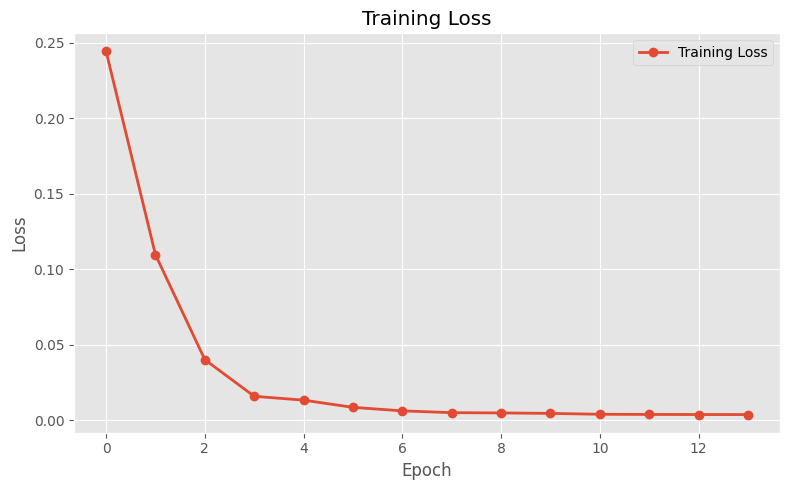

In [358]:
## Training Loss Curve

plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

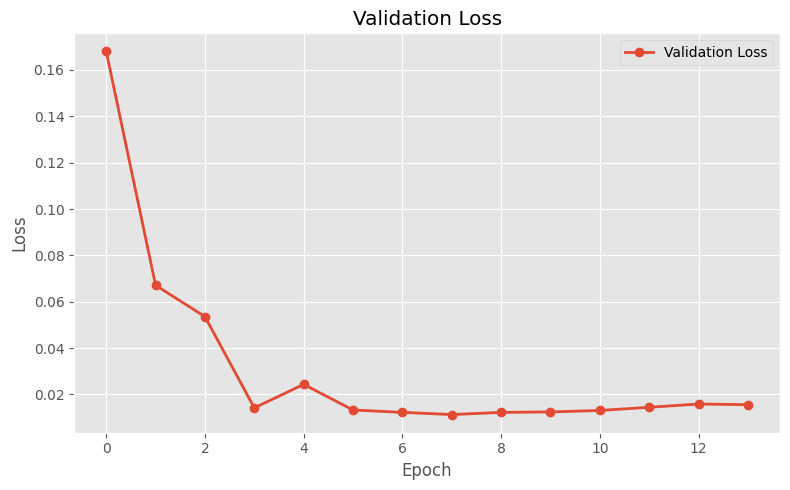

In [359]:
## Validation Loss Curve

plt.figure(figsize=(8,5))

plt.plot(
    history["valid_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.title("Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

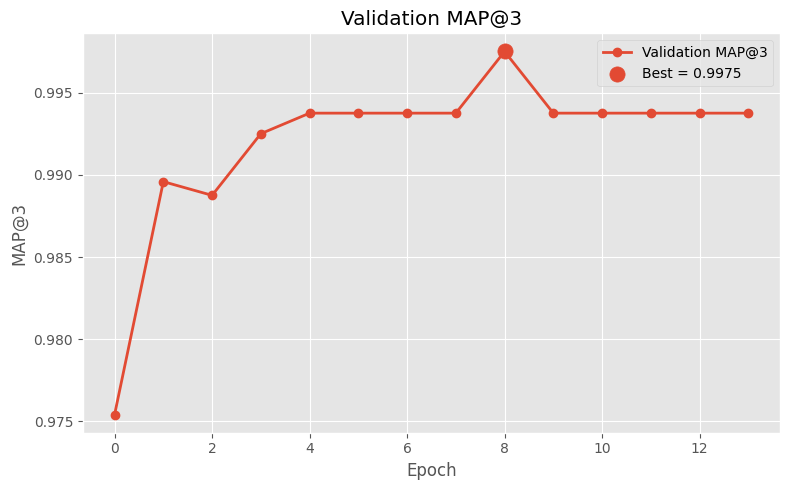

In [360]:
## Validation MAP@3 Curve

plt.figure(figsize=(8,5))

plt.plot(
    history["map3"],
    marker="o",
    linewidth=2,
    label="Validation MAP@3"
)

best_epoch = np.argmax(history["map3"])

best_score = np.max(history["map3"])

plt.scatter(
    best_epoch,
    best_score,
    s=120,
    label=f"Best = {best_score:.4f}"
)

plt.title("Validation MAP@3")

plt.xlabel("Epoch")

plt.ylabel("MAP@3")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

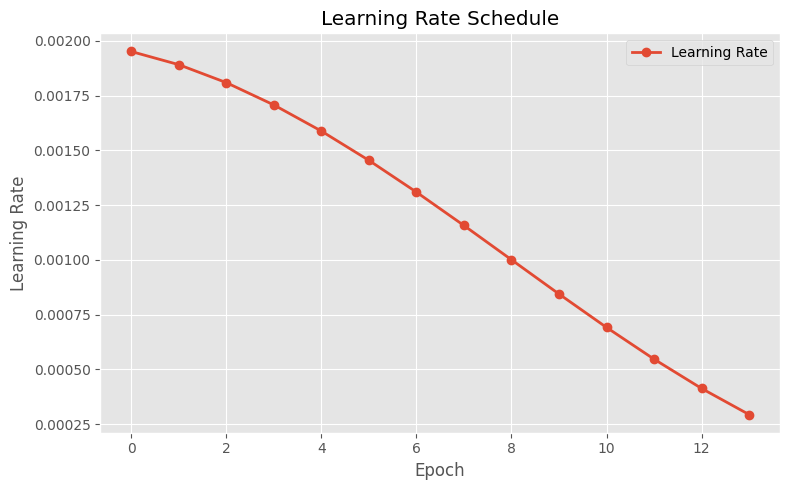

In [361]:
## Learning Rate Curve

plt.figure(figsize=(8,5))

plt.plot(
    history["lr"],
    marker="o",
    linewidth=2,
    label="Learning Rate"
)

plt.title("Learning Rate Schedule")

plt.xlabel("Epoch")

plt.ylabel("Learning Rate")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

In [362]:
history_df = pd.DataFrame(history)

display(history_df)

,train_loss,valid_loss,train_acc,valid_acc,map3,lr
0,0.244118,0.167968,0.902375,0.9320,0.975417,0.001951
1,0.109539,0.067107,0.953000,0.9710,0.989583,0.001891
2,0.040081,0.053562,0.985125,0.9830,0.988750,0.001809
3,0.015841,0.014193,0.994500,0.9925,0.992500,0.001707
4,0.013294,0.024353,0.995000,0.9930,0.993750,0.001588
5,0.008519,0.013283,0.995625,0.9940,0.993750,0.001454
6,0.006197,0.012272,0.996750,0.9940,0.993750,0.001309
7,0.005005,0.011318,0.997125,0.9950,0.993750,0.001157
8,0.004821,0.012257,0.996875,0.9940,0.997500,0.001001
9,0.004521,0.012461,0.997000,0.9940,0.993750,0.000844


In [363]:
## Best Epoch
print("="*60)

print("Best Epoch")

print("="*60)

best_epoch = np.argmax(history["map3"]) + 1

best_map = np.max(history["map3"])

print(f"Epoch : {best_epoch}")

print(f"MAP@3 : {best_map:.5f}")

Best Epoch
Epoch : 9
MAP@3 : 0.99750


In [364]:
### Final Summary
print("="*70)

print("FINAL TRAINING SUMMARY")

print("="*70)

print(f"Total Epochs      : {len(history['train_loss'])}")

print(f"Best Epoch        : {best_epoch}")

print(f"Best MAP@3        : {best_map:.5f}")

print(f"Final Train Loss  : {history['train_loss'][-1]:.4f}")

print(f"Final Valid Loss  : {history['valid_loss'][-1]:.4f}")

print("="*70)

FINAL TRAINING SUMMARY
Total Epochs      : 14
Best Epoch        : 9
Best MAP@3        : 0.99750
Final Train Loss  : 0.0037
Final Valid Loss  : 0.0156


## Part - 6 (Submission generation)

In [365]:
## Pairwise Test Dataset

OPTIONS = ["A", "B", "C", "D", "E"]

pairwise_test = []

for _, row in test.iterrows():

    for option in OPTIONS:

        pairwise_test.append({

            "question_id": int(row["id"]),

            "option": option,

            "text": f"Question: {row['prompt']} Answer: {row[option]}"

        })

pairwise_test = pd.DataFrame(pairwise_test)

print(pairwise_test.shape)
pairwise_test.head()

(2500, 3)


,question_id,option,text
0,1,A,Question: Pick the best possible answer: What ...
1,1,B,Question: Pick the best possible answer: What ...
2,1,C,Question: Pick the best possible answer: What ...
3,1,D,Question: Pick the best possible answer: What ...
4,1,E,Question: Pick the best possible answer: What ...


In [366]:
def encode_tokens(tokens, vocab):
    """
    Convert list of tokens into list of integer ids.
    Unknown words -> <UNK>
    """

    unk_idx = vocab["<UNK>"]

    return [vocab.get(token, unk_idx) for token in tokens]

In [367]:
### Apply Same Preprocessing
### Exactly the same preprocessing used during training:

pairwise_test["clean_text"] = pairwise_test["text"].apply(clean_text)

pairwise_test["tokens"] = pairwise_test["clean_text"].apply(tokenize)

pairwise_test["encoded"] = pairwise_test["tokens"].apply(
    lambda x: encode_tokens(x, vocab)
)

pairwise_test["input_ids"] = pairwise_test["encoded"].apply(
    pad_sequence
)

In [368]:
# TEST DATASET
class TestDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe.reset_index(drop=True)

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        return {

            "input_ids": torch.tensor(
                row["input_ids"],
                dtype=torch.long
            ),

            "question_id": torch.tensor(
                int(row["question_id"]),
                dtype=torch.long
            ),

            "option": row["option"]

        }

In [369]:
def test_collate_fn(batch):

    input_ids = torch.stack([
        x["input_ids"] for x in batch
    ])

    question_ids = torch.tensor([
        x["question_id"] for x in batch
    ])

    options = [
        x["option"] for x in batch
    ]

    return {
        "input_ids": input_ids,
        "question_ids": question_ids,
        "options": options
    }

In [370]:
### Test DataLoader
test_dataset = TestDataset(pairwise_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    collate_fn=test_collate_fn,
    num_workers=0
)

In [371]:
# model.load_state_dict(
#     torch.load("best_model.pth", map_location=DEVICE)
# )

torch.save(model.state_dict(), "best_model.pth")

model.to(DEVICE)

model.eval()

BiLSTMAttention(
  (embedding): Embedding(3018, 300, padding_idx=0)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [372]:
### Load Best Model
model = BiLSTMAttention(
    vocab_size=len(vocab),
    embedding_dim=CFG.EMBEDDING_DIM,
    hidden_dim=CFG.HIDDEN_DIM,
    dropout=CFG.DROPOUT
).to(DEVICE)

model.load_state_dict(
    torch.load("best_model.pth", map_location=DEVICE)
)

model.eval()

BiLSTMAttention(
  (embedding): Embedding(3018, 300, padding_idx=0)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [373]:
scores = []
question_ids = []
options = []

model.eval()

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(DEVICE)

        logits = model(input_ids)

        probs = torch.sigmoid(logits)

        # Convert to 1D list regardless of shape
        batch_scores = probs.detach().cpu().numpy().reshape(-1)

        batch_qids = batch["question_ids"].cpu().numpy()

        batch_options = batch["options"]

        # Safety check
        assert len(batch_scores) == len(batch_qids) == len(batch_options)

        scores.extend(batch_scores.tolist())
        question_ids.extend(batch_qids.tolist())
        options.extend(batch_options)

  0%|          | 0/79 [00:00<?, ?it/s]

In [374]:
prediction_df = pd.DataFrame({
    "question_id": question_ids,
    "option": options,
    "score": scores
})

print(prediction_df.shape)
print(prediction_df["question_id"].nunique())

(2500, 3)
500


In [375]:
prediction_df["question_id"] = prediction_df["question_id"].apply(
    lambda x: int(x.item()) if torch.is_tensor(x) else int(x)
)


In [376]:
print(prediction_df.groupby("question_id").size().value_counts())

5    500
Name: count, dtype: int64


In [377]:
submission = []

for qid, group in prediction_df.groupby("question_id"):

    ranked = group.sort_values(
        "score",
        ascending=False
    )

    top3 = ranked["option"].tolist()[:3]

    submission.append({
        "ID": int(qid),
        "Prediction": " ".join(top3)
    })

submission = pd.DataFrame(submission)

submission = submission.sort_values("ID").reset_index(drop=True)

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.shape)
print(submission.head())

(500, 2)
   ID Prediction
0   1      A B C
1   2      B A C
2   3      E C B
3   4      A B C
4   5      E D A


In [378]:
print(test.shape)

print(pairwise_test.shape)

print(type(test_dataset))

print(len(test_dataset))

print(next(iter(test_loader))["question_ids"][:10])

(500, 7)
(2500, 7)
<class '__main__.TestDataset'>
2500
tensor([1, 1, 1, 1, 1, 2, 2, 2, 2, 2])


In [379]:
all_scores = []

model.eval()

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(DEVICE)

        outputs = model(input_ids)

        probs = torch.sigmoid(outputs)

        all_scores.extend(
            probs.cpu().numpy().tolist()
        )

import numpy as np

print("Min :", np.min(all_scores))
print("Max :", np.max(all_scores))
print("Mean:", np.mean(all_scores))
print("Std :", np.std(all_scores))

Min : 0.9999954700469971
Max : 0.9999991655349731
Mean: 0.999996927022934
Std : 8.15077039231269e-07


In [380]:
print(pairwise_train["label"].value_counts())
prediction_df[prediction_df["question_id"] == 1]

label
0    8000
1    2000
Name: count, dtype: int64


,question_id,option,score
0,1,A,0.999997
1,1,B,0.999997
2,1,C,0.999997
3,1,D,0.999997
4,1,E,0.999997


In [381]:
with torch.no_grad():

    batch = next(iter(test_loader))

    input_ids = batch["input_ids"].to(DEVICE)

    outputs = model(input_ids)

    print(outputs.shape)

    print(outputs)

torch.Size([32])
tensor([12.6351, 12.6351, 12.6351, 12.6351, 12.6351, 12.6351, 12.6680, 12.6351,
        12.6351, 12.6516, 12.6351, 12.8083, 12.8083, 12.7162, 12.9487, 12.9080,
        12.9080, 12.9217, 12.9080, 12.9217, 12.8661, 12.8661, 12.8661, 12.8942,
        12.8942, 12.7162, 12.7003, 12.6842, 12.7162, 12.6017, 12.8661, 12.9751],
       device='cuda:0')


In [382]:
submission.head()

,ID,Prediction
0,1,A B C
1,2,B A C
2,3,E C B
3,4,A B C
4,5,E D A
